In [2]:
import translators as ts
import time
from nltk.translate import bleu_score
import numpy as np
from bleurt import score
import json
import pandas as pd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pathlib
import os

2025-11-07 10:00:35.748477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import datasets

/home/andreas/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Get SMOLSent En->Cantonese data

In [4]:
rel_path = pathlib.Path(".")
en_yue_sentences_validation = pd.read_json(path_or_buf=rel_path / "smoldata/smol_en_yue_sentences/validation.json", lines=True)

In [5]:
yue_zh_characters_validation = datasets.load_dataset("google/smol", "gatitos__yue_zh")

Benchmark sentences on various translation sites using bleu to demonstrate that chinese models don't necessarily outperform cantonese models

In [6]:
# run this to skip scraping
with open(r"translation_service_en_yue_sentence_validation.json", "r") as f:
    all_trans = json.load(f)

In [10]:
services = ["bing", "google"]
langs = {
    "bing": ["chinese (simplified)", "chinese (traditional)", "cantonese"],
    "google": ["chinese"]
}

lang_map = {
    "bing": {"chinese (simplified)" : "zh-Hans", "chinese (traditional)": "zh-Hant", "cantonese": "yue", "english": "en"},
    "google": {"chinese": "zh", "english": "en"}
}

all_trans = []


if os.path.isfile(rel_path / "translation_service_en_yue_sentence_validation.json"):
    with open(r"translation_service_en_yue_sentence_validation.json", "r") as f:
        all_trans = json.load(f)
else:

    for index, sentence in tqdm(en_yue_sentences_validation.iterrows(), total=en_yue_sentences_validation.shape[0]):
    
        translations = {
            "original_eng": sentence["src"],
            "original_yue": sentence["trg"]
        }

        for service in services:

            attempts = 0
            while attempts < 3:
                try:
                    trans = {language: {"translation":ts.translate_text(sentence["trg"], translator="bing", from_language=lang_map[service][language], to_language=lang_map[service]["english"])} for language in langs[service] }
                    translations[service] = trans
                    break
                except KeyboardInterrupt:
                    sys.exit(1)
                except:
                    tqdm.write(f"error on sentece {sentence['id']}, retrying... ({attempts + 1})")
                    attempts += 1
                    time.sleep(3)
            if attempts == 3:
                tqdm.write(f"skipped sentence {sentence['id']} after {attempts+1} attempts")
                continue
        
        all_trans.append(translations)

In [13]:
def bleu(ref, cand):
    return bleu_score.sentence_bleu(
            [ref.split()], 
            cand.split(), 
                #use smoothing method 7 that had best chinese->english human-evaluation corerlation from https://aclanthology.org/W14-3346/
            smoothing_function= bleu_score.SmoothingFunction().method7 
            )

def benchmark(all_trans, metric, metric_name, services, langs):
    with tqdm(total = len(all_trans) * np.sum([len(langs[service]) for service in services]), leave=True) as pbar:
        for i, trans in enumerate(all_trans):
            for service in services:
                for lang in langs[service]:
                    all_trans[i][service][lang][metric_name] = metric(trans["original_eng"], trans[service][lang]["translation"])
                    pbar.update()

def print_benchmark(all_trans, metric_name, services, langs):
    for service in services:
            for lang in langs[service]:
                print(f'{service:10s} - {lang:25s}: {np.mean([trans[service][lang][metric_name] for trans in all_trans]):.4f} {metric_name}')

In [14]:
benchmark(all_trans, bleu, "bleu", services, langs)
print_benchmark(all_trans, "bleu", services, langs)

100%|██████████| 692/692 [00:00<00:00, 6196.25it/s]

bing       - chinese (simplified)     : 0.2920 bleu
bing       - chinese (traditional)    : 0.3061 bleu
bing       - cantonese                : 0.2885 bleu
google     - chinese                  : 0.2929 bleu


Since BLEU is a n-gram based evaluation proxy it evaluates sentences badly when they don't share vocabulary or word order with the reference, even if the semantic meaning is conserved. This can be seen below where Bing's chinese traditional model scores vastly above the others even though it has the same semantic meaning.  

In [15]:
def print_sentences(sent_trans):
    print(f'{"original":29s} : {sent_trans["original_eng"]}')
    [print(f'bing   {lang:22s} : {sent_trans["bing"][lang]["translation"]}') for lang in langs["bing"]]
    [print(f'google {lang:22s} : {sent_trans["google"][lang]["translation"]}') for lang in langs["google"]]
    print(f'{"original yue":29s} : {sent_trans["original_yue"]}')

In [17]:
i = 8
print_sentences(all_trans[i])
print("\n")
print_benchmark([all_trans[i]], "bleu", services, langs)

original                      : Since James’ injury, they have the fourth-best defensive rating in the league.
bing   chinese (simplified)   : Since James got injured, they have had the fourth best defensive rating in the league.
bing   chinese (traditional)  : Since James got injured, they have the fourth-best defensive rating in the league.
bing   cantonese              : Since James got injured, they have had the fourth-best defense in the league.
google chinese                : Since James got injured, they have had the fourth best defensive rating in the league.
original yue                  : 自從占姆士受傷之後，佢哋喺聯賽入面有第四好嘅防守率。


bing       - chinese (simplified)     : 0.3849 bleu
bing       - chinese (traditional)    : 0.7682 bleu
bing       - cantonese                : 0.2596 bleu
google     - chinese                  : 0.3849 bleu


For that reason we instead switch to the model-based evaluation metric BLEURT

In [20]:
## ../bleurt/BLEURT-20
scorer = score.BleurtScorer(pathlib.Path("BLEURT-20"))

INFO:tensorflow:Reading checkpoint BLEURT-20.


INFO:tensorflow:Reading checkpoint BLEURT-20.


INFO:tensorflow:Config file found, reading.


INFO:tensorflow:Config file found, reading.


INFO:tensorflow:Will load checkpoint BLEURT-20


...

INFO:tensorflow:Creating Eager Mode predictor.


INFO:tensorflow:Loading model.


INFO:tensorflow:Loading model.
2025-11-07 10:09:01.471502: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 256307200 exceeds 10% of free system memory.


INFO:tensorflow:BLEURT initialized.


INFO:tensorflow:BLEURT initialized.


In [44]:
def bleurt(ref, cand):
    return scorer.score(references=[ref], candidates=[cand])[0]

if os.path.isfile(rel_path /"all_trans_bleurt-20.json"):
    with open(r"all_trans_bleurt-20.json", "r") as f:
        all_trans = json.load(f)
else:
    benchmark(all_trans, bleurt, "bleurt", services, langs)

print_benchmark(all_trans, "bleurt", services, langs)

bing       - chinese (simplified)     : 0.7471 bleurt
bing       - chinese (traditional)    : 0.7527 bleurt
bing       - cantonese                : 0.7487 bleurt
google     - chinese                  : 0.7478 bleurt


In [45]:
json.dump(all_trans, open("all_trans_bleurt-20.json", "w"), indent=4, ensure_ascii=False)

In [47]:
i = 8
print_sentences(all_trans[i])
print("\n")
print_benchmark([all_trans[i]], "bleurt", services, langs)

original                      : Since James’ injury, they have the fourth-best defensive rating in the league.
bing   chinese (simplified)   : Since James got injured, they have had the fourth best defensive rating in the league.
bing   chinese (traditional)  : Since James got injured, they have the fourth-best defensive rating in the league.
bing   cantonese              : Since James got injured, they have had the fourth-best defense in the league.
google chinese                : Since James got injured, they have had the fourth best defensive rating in the league.
original yue                  : 自從占姆士受傷之後，佢哋喺聯賽入面有第四好嘅防守率。


bing       - chinese (simplified)     : 0.8333 bleurt
bing       - chinese (traditional)    : 0.8670 bleurt
bing       - cantonese                : 0.7847 bleurt
google     - chinese                  : 0.8333 bleurt


Now we can see that we have a better evaluation measure, the two translations that had the same semantic meaning but scored much worse now have around the same score, and the translation that did not translate "rating" scored worse than the others. 

Next we will use the bleurt evaluation metric to filter for bad translations that we can look for patterns in. 

In [37]:
filter_value = 0.6
bad_translations = [trans for trans in all_trans if np.all([np.all([trans[service][lang]["bleurt"] < filter_value for lang in langs[service]]) for service in services])]
print_sentences(bad_translations[0])
print(len(bad_translations))

original                      : Keep your sink shining and free of dirty dishes at all times.
bing   chinese (simplified)   : Always keep your zinc plate tidy, and don't let dirty dishes pile up.
bing   chinese (traditional)  : Keep your zinc tray upright at all times and don't let dirty dishes pile up.
bing   cantonese              : Always keep your zinc plate upright, and don't let dirty dishes pile up.
google chinese                : Always keep your zinc plate tidy, and don't let dirty dishes pile up.
original yue                  : 時刻保持你個鋅盤立立令，唔好俾污糟碗碟堆積。
5


Many bad translations mistranslate words, so we believe it is likely the case that bad translations have more cantonese-specific characters in them, so we plot this relation to see if there is any correlation. 

In [38]:
with open("character_classification.json", "r") as f:
    character_classfication = json.load(f)

In [39]:
def canto_characters_in_sentence(sentence):
    canto_only = 0
    for x in sentence:
        if x in character_classfication.keys():
            if character_classfication[x] == "CANTO_ONLY":
                canto_only += 1
    return canto_only, len(sentence)

all_translations_canto_score = {}
for service in services:
    
    all_translations_canto_score[service] = {}
    for lang in langs[service]:
        all_translations_canto_score[service][lang] = []
        for i in range(len(all_trans)):
            score = all_trans[i][service][lang]["bleurt"]
            canto,length = canto_characters_in_sentence(all_trans[i]["original_yue"])
            all_translations_canto_score[service][lang].append((canto/length, score))

Text(0.5, 0.98, 'bleurt vs cantonese character presence')

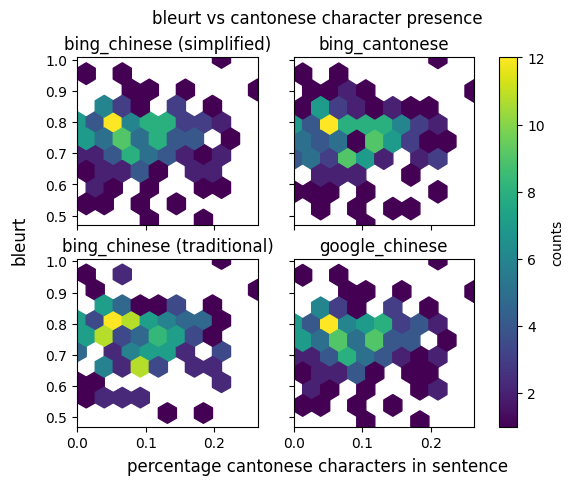

In [40]:
fig, axs = plt.subplots(2,2,sharey=True,sharex=True)

fig_map = {"bing": {"chinese (simplified)": (0,0), "chinese (traditional)": (1,0), "cantonese": (0,1)}, "google": {"chinese": (1,1)}}

hexbin_size = 10
for service in services:
    for lang in langs[service]:
        z = axs[fig_map[service][lang]].hexbin(
    np.array(all_translations_canto_score[service][lang])[:,0].flatten(), 
    np.array(all_translations_canto_score[service][lang])[:,1].flatten(), 
    gridsize=hexbin_size,
    #cmap="ciridis", 
    mincnt=1
    )

        axs[fig_map[service][lang]].set_title(service + "_" + lang)
        axs[fig_map[service][lang]].margins(0)

cb = fig.colorbar(z, ax=axs, label='counts')


fig.supxlabel("percentage cantonese characters in sentence")
fig.supylabel("bleurt")
fig.suptitle("bleurt vs cantonese character presence")

/tmp/ipykernel_9063/3435023842.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


Text(0.5, 1.0, 'bing & google model translations')

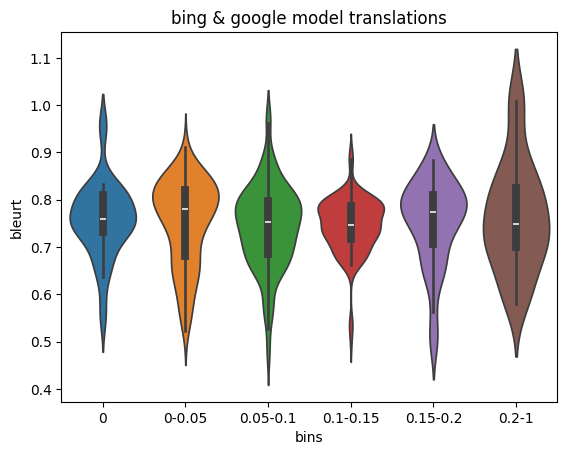

In [41]:
bins = [0]

v = np.array(all_translations_canto_score["bing"]["chinese (simplified)"] + all_translations_canto_score["bing"]["chinese (traditional)"] + all_translations_canto_score["bing"]["cantonese"] + all_translations_canto_score["google"]["chinese"])

bin_ranges = [0, 0.0001, 0.05, 0.1, 0.15, 0.2, 1]


bins = [np.argwhere((v[:,0] >= bin_ranges[i]) & (v[:,0] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

ax = sns.violinplot([v[bin, 1].flatten() for bin in bins])
xtick_labels = [str(bin_ranges[i]) + "-" + str(bin_ranges[i+1]) for i in range(len(bin_ranges)-1)]
xtick_labels[0] = "0"
xtick_labels[1] = "0-0.05"
ax.set_xticklabels(xtick_labels)

ax.set_ylabel("bleurt")
ax.set_xlabel("bins")
ax.set_title("bing & google model translations")

Generally the models do very well when there are no cantonese characters. Beyond that there may be a slight negative correlation between average performance and the number of cantonese characters. 

We do another test with a local large language model (MADLAD400 3B-mt)

In [42]:
with open(r"sentence_translations_madlad400-3b.json", "r") as f:
    madlad_translations = json.load(f)

In [ ]:
if os.path.isfile(rel_path /"sentence_translations_madlad400-3b_bleurt.json"):
    with open(r"sentence_translations_madlad400-3b_bleurt.json", "r") as f:
        madlad_translations = json.load(f)
else:
    for x in tqdm(madlad_translations):
        x["bleurt"] = bleurt(x["original"], x["cantonese"])
        canto, length = canto_characters_in_sentence(x["original_yue"])
        x["canto_percent"] = canto/length

100%|██████████| 173/173 [09:39<00:00,  3.35s/it]


In [49]:
json.dump(madlad_translations, open("sentence_translations_madlad400-3b_bleurt.json", "w"), indent=4, ensure_ascii=False)

In [50]:
[np.mean([x["bleurt"] for x in madlad_translations])]

[0.6992631363386363]

Text(0, 0.5, 'bleurt')

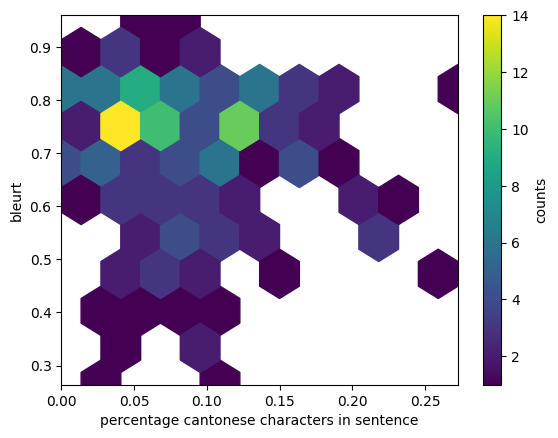

In [51]:
madlad_relation = np.array([(x["canto_percent"], x["bleurt"]) for x in madlad_translations])
z = plt.hexbin(madlad_relation[:,0], madlad_relation[:,1], gridsize=hexbin_size, mincnt=1)

plt.colorbar(z, label="counts")
plt.margins(0)

plt.xlabel("percentage cantonese characters in sentence")
plt.ylabel("bleurt")

/tmp/ipykernel_9063/3815910705.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


Text(0.5, 1.0, 'madlad400 3B-mt translations')

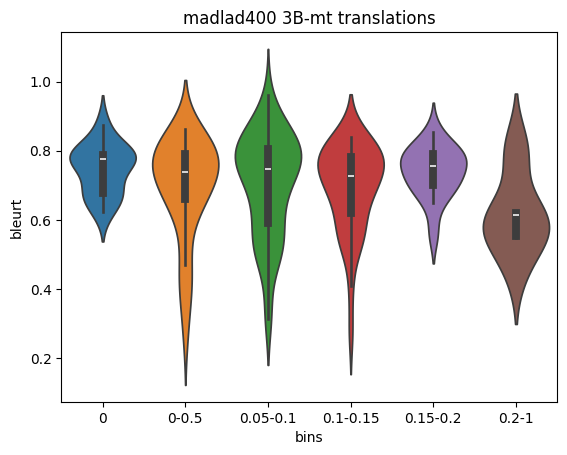

In [52]:
v = np.array(madlad_relation)

bin_ranges = [0, 0.001, 0.05, 0.1, 0.15, 0.2, 1]

bins = [np.argwhere((v[:,0] >= bin_ranges[i]) & (v[:,0] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

ax = sns.violinplot([v[bin, 1].flatten() for bin in bins])
xtick_labels = [str(bin_ranges[i]) + "-" + str(bin_ranges[i+1]) for i in range(len(bin_ranges)-1)]
xtick_labels[0] = "0"
xtick_labels[1] = "0-0.5"
ax.set_xticklabels(xtick_labels)

ax.set_ylabel("bleurt")
ax.set_xlabel("bins")
ax.set_title("madlad400 3B-mt translations")

We see the same pattern, the model does well on sentences that only contain mandarin characters, somewhat well on sentences that contain a small amount of cantonese characters and all over the place on other sentences. The negative correlation between number of cantonese characters and bleurt score is more apparent on this model. 

In [53]:
def canto_characters_in_sentence(sentence):
    canto_chars = []
    for x in sentence:
        if x in character_classfication.keys():
            if character_classfication[x] == "CANTO_ONLY":
                canto_chars.append(x)
    return canto_chars

In [54]:
madlad_translations[0]

{'original': 'Processes outgoing mail, maintains files, orders supplies, and ships packages.',
 'original_yue': '處理寄出嘅郵件，維護文件，訂購物資同埋寄送包裹。',
 'cantonese': 'It handles outgoing mail, maintains documents, orders supplies and sends parcels.',
 'bleurt': 0.7751072645187378,
 'canto_percent': 0.041666666666666664}

In [55]:
"長度" in yue_zh_characters_validation["train"]["src"]

True

In [56]:
[x in yue_zh_characters_validation["train"]["src"] for x in canto_characters_in_sentence(madlad_translations[15]["original_yue"])]

[False, True]

In [ ]:
bad_translations = []
for trans in madlad_translations:
    if trans["bleurt"] < 0.5:
        if np.all([x in yue_zh_characters_validation["train"]["src"] for x in canto_characters_in_sentence(trans["original_yue"])]):
            bad_translations.append(trans)



#bad_translations = [trans for trans in madlad_translations if trans["bleurt"] < -0.5 and np.all([x in yue_zh_characters_validation["train"]["src"] for (i, x) in canto_characters_in_sentence(trans["original_yue"])])]
len(bad_translations)

10

In [60]:
[x for x in madlad_translations if x["original"] == "Rohan was my sibling who always flew a kite at noon, even if it was cloudy."]

[{'original': 'Rohan was my sibling who always flew a kite at noon, even if it was cloudy.',
  'original_yue': '羅漢係我兄弟，佢成日喺正午放風箏，就算天陰陰。',
  'cantonese': 'The bridge is opened to the public at noon, and closed at midnight.',
  'bleurt': 0.31466948986053467,
  'canto_percent': 0.08695652173913043}]

In [61]:
bad_translations[0]

{'original': 'Rohan was my sibling who always flew a kite at noon, even if it was cloudy.',
 'original_yue': '羅漢係我兄弟，佢成日喺正午放風箏，就算天陰陰。',
 'cantonese': 'The bridge is opened to the public at noon, and closed at midnight.',
 'bleurt': 0.31466948986053467,
 'canto_percent': 0.08695652173913043}

In [62]:
canto_characters_in_sentence(bad_translations[0]["original_yue"])

['佢', '喺']

In [63]:
[x for x in yue_zh_characters_validation["train"] if x["src"] in canto_characters_in_sentence(bad_translations[0]["original_yue"]) ]

[{'src': '喺', 'trgs': ['在'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True},
 {'src': '佢', 'trgs': ['他'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True},
 {'src': '佢', 'trgs': ['它'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True},
 {'src': '喺', 'trgs': ['在'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True},
 {'src': '佢', 'trgs': ['她'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True},
 {'src': '佢', 'trgs': ['他'], 'sl': 'yue', 'tl': 'zh', 'is_source_orig': True}]